# 04. Results, figures and tables

Every number, table and figure in the paper, recomputed from the raw per-condition outputs in `results/`
with the study's own crossed bootstrap (`crossed_summary`, 10,000 resamples of reciters and verses,
seed 20270911). The last section checks each recomputed value against the value printed in the paper.

Notation: PV = phase vocoder, RB = Rubber Band; Local / Global / Silence arms; $k$ = local stretch factor;
$\Delta$ = WER(Local) $-$ WER(Global). Models: Tarteel (public checkpoint), M0 (heard none of the
evaluated reciters), M1 (their voices), M2 (also the evaluated recordings).

In [1]:
import sys, json, gzip, collections
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src" / "analysis"))
import numpy as np
import stats as S
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
print("statistics code executed from the original analysis module:\n")
print(S.PAPER_STATS_SOURCE.splitlines()[0], "...")
D = {m: S.merged(m) for m in S.MODELS}
for m in S.MODELS:
    print(f"{m:8s} {sum(len(r) for r in D[m].values()):6d} scored conditions (5 confirmatory reciters)")

statistics code executed from the original analysis module:

def crossed_summary(primary, rng): ...


tarteel    6502 scored conditions (5 confirmatory reciters)
M0         6502 scored conditions (5 confirmatory reciters)
M1         6502 scored conditions (5 confirmatory reciters)
M2         6502 scored conditions (5 confirmatory reciters)


## Table 1: WER by arm at $k=4$

In [2]:
A = {m: {"Clean": S.summary(D[m], S.arm("baseline", 1.0))[0],
         "PV L": S.summary(D[m], S.arm("nucleus", 4.0))[0], "PV G": S.summary(D[m], S.arm("global", 4.0))[0],
         "RB L": S.summary(D[m], S.arm("nucleus_rb", 4.0))[0], "RB G": S.summary(D[m], S.arm("global_rb", 4.0))[0],
         "Silence": S.summary(D[m], S.arm("silence", 4.0))[0]} for m in S.MODELS}
import pandas as pd
pd.DataFrame(A).T.round(3)

,Clean,PV L,PV G,RB L,RB G,Silence
tarteel,0.010,0.393,0.219,0.194,0.015,0.336
M0,0.067,0.459,0.414,0.227,0.115,0.471
M1,0.046,0.437,0.393,0.175,0.062,0.449
M2,0.025,0.433,0.347,0.160,0.067,0.428


## Contrasts, round trip and dose response

In [3]:
R = {}
for m in S.MODELS:
    d = D[m]
    R[m] = {"PV k=4": S.summary(d, S.contrast("nucleus", "global", 4.0)), "RB k=4": S.summary(d, S.contrast("nucleus_rb", "global_rb", 4.0)),
            "PV k=2": S.summary(d, S.contrast("nucleus", "global", 2.0)), "PV k=6": S.summary(d, S.contrast("nucleus", "global", 6.0)),
            "RB k=2": S.summary(d, S.contrast("nucleus_rb", "global_rb", 2.0)), "RB k=6": S.summary(d, S.contrast("nucleus_rb", "global_rb", 6.0)),
            "RT PV global": S.summary(d, lambda r: r[("global_rt", 4.0)] - r[("sham_pv_global", 1.0)]),
            "RT PV local": S.summary(d, lambda r: r[("nucleus_rt", 4.0)] - r[("sham_pv_local", 1.0)]),
            "RT RB global": S.summary(d, lambda r: r[("global_rt_rb", 4.0)] - r[("baseline", 1.0)]),
            "RT RB local": S.summary(d, lambda r: r[("nucleus_rt_rb", 4.0)] - r[("baseline", 1.0)])}
fmt = lambda x: f"{x[0]:+.3f} [{x[1]:+.3f}, {x[2]:+.3f}]"
pd.DataFrame({m: {k: fmt(v) for k, v in R[m].items()} for m in S.MODELS})

,tarteel,M0,M1,M2
PV k=4,"+0.174 [+0.088, +0.272]","+0.046 [-0.049, +0.140]","+0.044 [-0.066, +0.147]","+0.086 [-0.021, +0.189]"
RB k=4,"+0.179 [+0.085, +0.386]","+0.111 [+0.028, +0.199]","+0.113 [+0.059, +0.178]","+0.093 [+0.034, +0.163]"
PV k=2,"-0.094 [-0.172, -0.011]","-0.213 [-0.322, -0.093]","-0.180 [-0.272, -0.096]","-0.198 [-0.293, -0.112]"
PV k=6,"-0.315 [-2.424, +0.259]","+0.111 [-0.008, +0.233]","+0.110 [+0.007, +0.220]","+0.162 [+0.043, +0.280]"
RB k=2,"+0.016 [+0.001, +0.051]","+0.036 [+0.005, +0.072]","+0.027 [+0.002, +0.061]","+0.023 [+0.000, +0.054]"
RB k=6,"+0.185 [+0.090, +0.284]","+0.131 [+0.052, +0.209]","+0.156 [+0.074, +0.236]","+0.168 [+0.081, +0.258]"
RT PV global,"+0.428 [+0.310, +0.549]","+0.621 [+0.508, +0.734]","+0.489 [+0.389, +0.586]","+0.519 [+0.411, +0.627]"
RT PV local,"+0.143 [+0.083, +0.220]","+0.266 [+0.173, +0.368]","+0.219 [+0.144, +0.301]","+0.228 [+0.150, +0.315]"
RT RB global,"+0.002 [+0.000, +0.010]","+0.018 [-0.008, +0.047]","+0.010 [-0.010, +0.033]","+0.016 [-0.001, +0.038]"
RT RB local,"-0.003 [-0.027, +0.006]","+0.003 [-0.022, +0.028]","+0.004 [+0.000, +0.013]","+0.002 [-0.012, +0.014]"


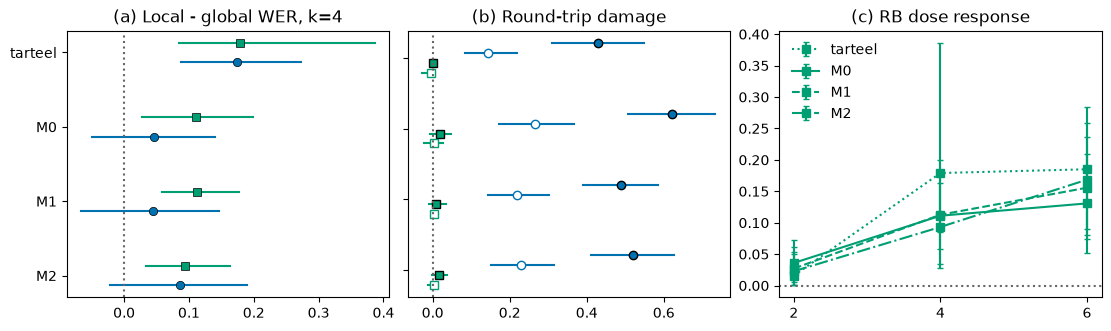

In [4]:
BLUE, GREEN, GRAY = "#0072B2", "#009E73", "#666666"
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), layout="constrained")
ys = np.arange(4)[::-1]
for off, key, col, mk in [(+0.13, "RB k=4", GREEN, "s"), (-0.13, "PV k=4", BLUE, "o")]:
    for y, m in zip(ys, S.MODELS):
        mu, lo, hi = R[m][key]; axes[0].plot([lo, hi], [y + off] * 2, color=col); axes[0].plot(mu, y + off, mk, color=col, mec="k", mew=.5)
axes[0].set_yticks(ys); axes[0].set_yticklabels(S.MODELS); axes[0].axvline(0, color=GRAY, ls=":"); axes[0].set_title("(a) Local - global WER, k=4")
for off, key, col, mk, fill in [(.21, "RT PV global", BLUE, "o", 1), (.07, "RT PV local", BLUE, "o", 0), (-.07, "RT RB global", GREEN, "s", 1), (-.21, "RT RB local", GREEN, "s", 0)]:
    for y, m in zip(ys, S.MODELS):
        mu, lo, hi = R[m][key]; axes[1].plot([lo, hi], [y + off] * 2, color=col); axes[1].plot(mu, y + off, mk, color=col if fill else "w", mec="k" if fill else col)
axes[1].set_yticks(ys); axes[1].set_yticklabels([]); axes[1].axvline(0, color=GRAY, ls=":"); axes[1].set_title("(b) Round-trip damage")
for m, ls in zip(S.MODELS, [":", "-", "--", "-."]):
    c = [R[m][f"RB k={k}"] for k in (2, 4, 6)]
    axes[2].errorbar([2, 4, 6], [v[0] for v in c], yerr=[[v[0] - v[1] for v in c], [v[2] - v[0] for v in c]], ls=ls, color=GREEN, marker="s", capsize=2, label=m)
axes[2].axhline(0, color=GRAY, ls=":"); axes[2].set_xticks([2, 4, 6]); axes[2].legend(frameon=False); axes[2].set_title("(c) RB dose response")
plt.show()

## Pre-specified tests (paper Table 2)

In [5]:
own = ["M0", "M1", "M2"]
dmg = lambda a, k: (lambda r: r[(a, k)] - r[("baseline", 1.0)])
T = {"E1 global PV damage, M1 - M2": S.summary(D["M1"], dmg("global", 4.0), other=D["M2"]),
     "E2 PV contrast, M2 - M1": S.summary(D["M2"], S.contrast("nucleus", "global", 4.0), other=D["M1"]),
     "E4 clean WER, M1 - M2": S.summary(D["M1"], S.arm("baseline", 1.0), other=D["M2"]),
     "RB contrast, M2 - M1 (post hoc)": S.summary(D["M2"], S.contrast("nucleus_rb", "global_rb", 4.0), other=D["M1"]),
     "D2 RB growth k=6 - k=2, M0": S.summary(D["M0"], lambda r: (r[("nucleus_rb", 6.0)] - r[("global_rb", 6.0)]) - (r[("nucleus_rb", 2.0)] - r[("global_rb", 2.0)])),
     "D2 RB growth k=6 - k=2, M1": S.summary(D["M1"], lambda r: (r[("nucleus_rb", 6.0)] - r[("global_rb", 6.0)]) - (r[("nucleus_rb", 2.0)] - r[("global_rb", 2.0)])),
     "D2 RB growth k=6 - k=2, M2": S.summary(D["M2"], lambda r: (r[("nucleus_rb", 6.0)] - r[("global_rb", 6.0)]) - (r[("nucleus_rb", 2.0)] - r[("global_rb", 2.0)]))}
for k, v in T.items(): print(f"{k:34s} {fmt(v)}")
print("E3 RB contrast > 0 in M0-M2:", all(R[m]["RB k=4"][1] > 0 for m in own))
print("D1 RB contrast at k=6 > 0 in M0-M2:", all(R[m]["RB k=6"][1] > 0 for m in own))
print("A1 round-trip correction: not testable (uncorrected PV and RB agree within their intervals)")

E1 global PV damage, M1 - M2       +0.025 [-0.027, +0.075]
E2 PV contrast, M2 - M1            +0.042 [-0.028, +0.115]
E4 clean WER, M1 - M2              +0.021 [+0.002, +0.052]
RB contrast, M2 - M1 (post hoc)    -0.019 [-0.061, +0.019]
D2 RB growth k=6 - k=2, M0         +0.095 [+0.015, +0.174]
D2 RB growth k=6 - k=2, M1         +0.129 [+0.054, +0.200]
D2 RB growth k=6 - k=2, M2         +0.146 [+0.060, +0.229]
E3 RB contrast > 0 in M0-M2: True
D1 RB contrast at k=6 > 0 in M0-M2: True
A1 round-trip correction: not testable (uncorrected PV and RB agree within their intervals)


### Membership probe (B1)
Score = WER increase under global stretching. The same recordings are scored under M2 (heard) and M1 (not heard); recordings counted as heard are those whose reciter's recording of the verse is in the EveryAyah training split.

In [6]:
full = {m: S.load(m, reciters=None) for m in ["M1", "M2"]}
mem = json.loads((ROOT / "data/split_membership.json").read_text())["study"]
members = [(n, v) for n, info in mem.items() for v, s in info["per_verse"].items() if "train" in s]
def auc(pos, neg):
    pos, neg = np.asarray(pos), np.asarray(neg)
    return float(((pos[:, None] > neg[None, :]).mean() + 0.5 * (pos[:, None] == neg[None, :]).mean()))
rng = np.random.default_rng(20260921)
for arm_name, k in [("global", 4.0), ("global_rb", 4.0)]:
    keys = [key for key in members if all((arm_name, k) in full[m].get(key, {}) and ("baseline", 1.0) in full[m].get(key, {}) for m in ["M1", "M2"])]
    s = {m: np.array([full[m][key][(arm_name, k)] - full[m][key][("baseline", 1.0)] for key in keys]) for m in ["M1", "M2"]}
    a = auc(-s["M2"], -s["M1"]); boots = []
    for _ in range(2000):
        idx = rng.integers(len(keys), size=len(keys)); boots.append(auc(-s["M2"][idx], -s["M1"][idx]))
    print(f"{arm_name}@{k:g}: n = {len(keys)} recordings, AUC = {a:.3f} [{np.percentile(boots, 2.5):.3f}, {np.percentile(boots, 97.5):.3f}]")

global@4: n = 272 recordings, AUC = 0.507 [0.485, 0.530]


global_rb@4: n = 272 recordings, AUC = 0.483 [0.464, 0.502]


## Recogniser-independent round-trip check
Median relative spectral error energy of the stretch-and-restore arms against the clean recording (computed from audio with `src/analysis`; audio is not redistributed, so the saved summary is loaded).

In [7]:
json.loads((ROOT / "results/spectral_rt.json").read_text())

{'global_rt': {'median': 0.436633825302124,
  'q25': 0.41589025408029556,
  'q75': 0.4554675444960594,
  'n': 210},
 'nucleus_rt': {'median': 0.12314852327108383,
  'q25': 0.08657833561301231,
  'q75': 0.16925958544015884,
  'n': 210},
 'global_rt_rb': {'median': 0.022034568712115288,
  'q25': 0.01846259692683816,
  'q75': 0.027851408813148737,
  'n': 210},
 'nucleus_rt_rb': {'median': 0.012029155157506466,
  'q25': 0.008960063336417079,
  'q75': 0.016216042451560497,
  'n': 210}}

## Check against the paper
The paper's numbers are generated into LaTeX macros. Each recomputed value below is formatted the same way and compared with the macro printed in the paper.

In [8]:
import re
paper = {}
for f in sorted((ROOT / "results/paper_macros").glob("*.tex")):
    paper.update(dict(re.findall(r"\\newcommand\{\\(\w+)\}\{([^}]*)\}", f.read_text())))
s3 = lambda v: f"{v:+.3f}".replace("-", "$-$"); f3 = lambda v: f"{v:.3f}"
tag = {"tarteel": "Tar", "M0": "Mz", "M1": "Mo", "M2": "Mt"}
expected = {}
for m, t in tag.items():
    expected[f"Clean{t}"] = f3(A[m]["Clean"])
    for key, nm in [("PV k=4", "Pv"), ("RB k=4", "Rb")]:
        expected[f"{nm}{t}"], expected[f"{nm}{t}Lo"], expected[f"{nm}{t}Hi"] = map(s3, R[m][key])
    expected[f"RtPvG{t}"], expected[f"RtPvL{t}"] = f3(R[m]["RT PV global"][0]), f3(R[m]["RT PV local"][0])
    expected[f"LocRb{t}"], expected[f"GloRb{t}"], expected[f"Sil{t}"] = f3(A[m]["RB L"]), f3(A[m]["RB G"]), f3(A[m]["Silence"])
    expected[f"PvTwo{t}"] = s3(R[m]["PV k=2"][0])
expected.update({"TestEOne": s3(T["E1 global PV damage, M1 - M2"][0]), "TestETwo": s3(T["E2 PV contrast, M2 - M1"][0]),
                 "TestEFour": s3(T["E4 clean WER, M1 - M2"][0]), "RbTwoMinusOne": s3(T["RB contrast, M2 - M1 (post hoc)"][0])})
ok = {k: paper.get(k) == v for k, v in expected.items()}
print(f"{sum(ok.values())} of {len(ok)} checked values match the paper exactly")
for k, v in ok.items():
    if not v: print("MISMATCH", k, "paper:", paper.get(k), "recomputed:", expected[k])

56 of 56 checked values match the paper exactly
